# SAIA2163 Final Project - Toxic Comment Detector

**Team:** Amil Hakim (A24AI0014) · Faris Haziq · Irfan Johan  
**Dataset:** Jigsaw Toxic Comment Classification Challenge  
**Task:** Binary classification - toxic vs non-toxic  

> This notebook loads all pretrained models and demonstrates the full pipeline end-to-end.  
> No retraining is performed. Models are loaded from GitHub and HuggingFace Hub.

## 1. Setup & Installation

In [ ]:
!pip install -q transformers datasets scikit-learn joblib lime torch seaborn matplotlib wordcloud accelerate langdetect
print('Installation complete')

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import torch
import joblib
import requests
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings('ignore', category=InconsistentVersionWarning)

print('All imports successful')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

/home/mel/final-project-nlp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful
PyTorch: 2.12.0+cu130
CUDA available: True


## 3. Configuration

In [3]:
GITHUB_RAW = 'https://raw.githubusercontent.com/lcokun/final-project-nlp/main'
HF_REPO    = 'lcokun/toxic-comment-distilbert'
SEED       = 42
MAX_LEN    = 128

CLASSICAL_MODELS = {
    'Logistic Regression (TF-IDF)': {
        'model': 'logistic_regression_tfidf.joblib',
        'vec':   'vectorizer_tfidf.joblib',
    },
    'Logistic Regression (BoW)': {
        'model': 'logistic_regression_bow.joblib',
        'vec':   'vectorizer_bow.joblib',
    },
    'SVM (TF-IDF)': {
        'model': 'svm_tfidf.joblib',
        'vec':   'vectorizer_tfidf.joblib',
    },
}

print('Config set')

Config set


## 4. Dataset Loading & Exploration

In [4]:
url = f'{GITHUB_RAW}/data/balanced_corpus.csv'
df = pd.read_csv(url)
df = df.dropna(subset=['preprocessed_text'])

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nClass distribution:')
print(df['toxic'].value_counts())
df.head()

Dataset shape: (30568, 2)
Columns: ['preprocessed_text', 'toxic']

Class distribution:
toxic
1    15286
0    15282
Name: count, dtype: int64


,preprocessed_text,toxic
0,faggot glad dead,1
1,chancer page hello welcom wikipedia answer que...,0
2,continu complet arsehol keep callin queerhol f...,1
3,could clarifi mean charg handl,0
4,say western racist like remov statement pro we...,1


## 5. Exploratory Data Analysis

### 5.1 Class Distribution

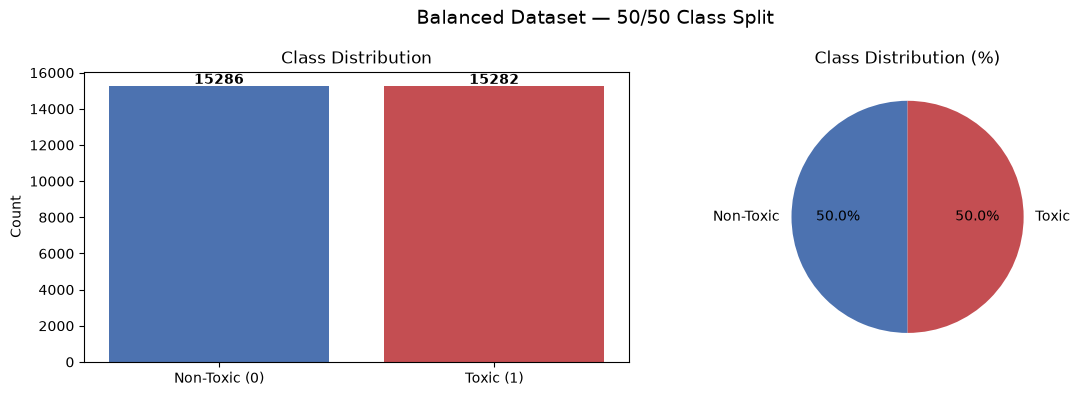

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['toxic'].value_counts()
axes[0].bar(['Non-Toxic (0)', 'Toxic (1)'], counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Non-Toxic', 'Toxic'],
            colors=['#4C72B0', '#C44E52'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Balanced Dataset — 50/50 Class Split', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Text Length Distribution

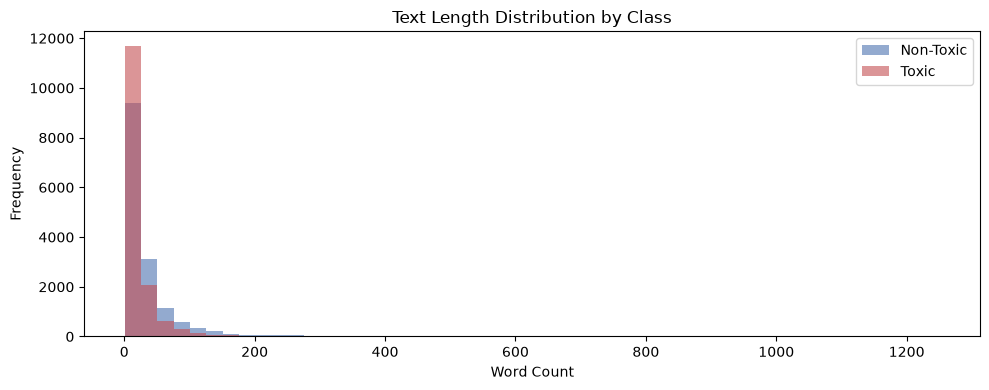

         count       mean        std  min  25%   50%   75%     max
toxic                                                             
0      15282.0  35.247284  52.837491  1.0  9.0  19.0  39.0  1250.0
1      15286.0  27.870404  68.675091  1.0  6.0  12.0  24.0  1250.0


In [6]:
df['text_length'] = df['preprocessed_text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(0, '#4C72B0', 'Non-Toxic'), (1, '#C44E52', 'Toxic')]:
    subset = df[df['toxic'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=name)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Text Length Distribution by Class')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('toxic')['text_length'].describe())

### 5.3 Word Cloud

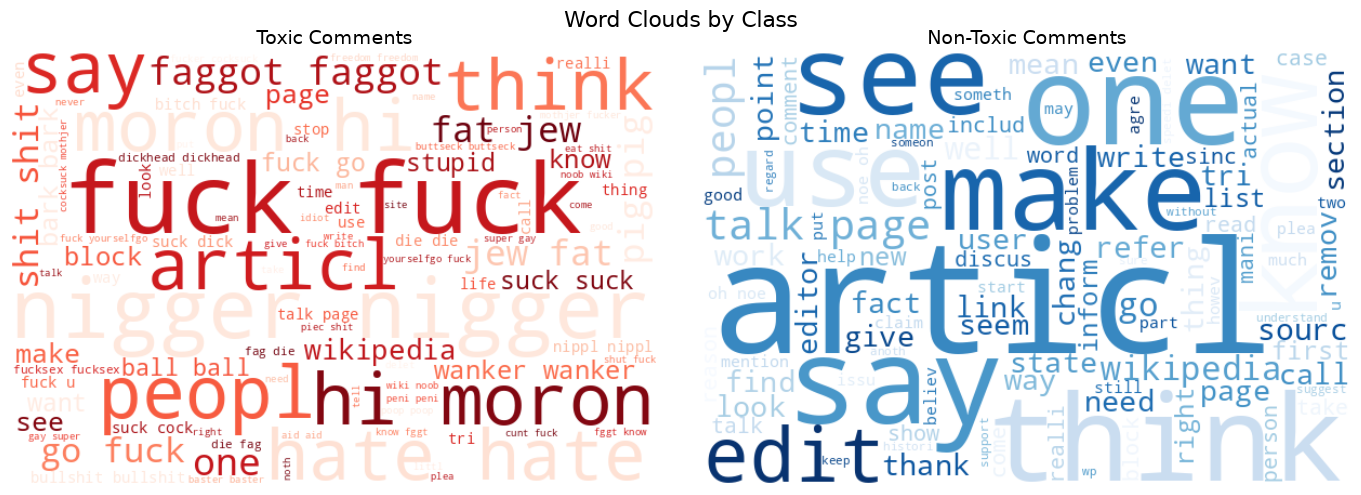

In [7]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (label, title, cmap) in enumerate([
    (1, 'Toxic Comments', 'Reds'),
    (0, 'Non-Toxic Comments', 'Blues')
]):
    text = ' '.join(df[df['toxic'] == label]['preprocessed_text'].dropna())
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(title, fontsize=14)

plt.suptitle('Word Clouds by Class', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Load Pretrained Classical Models

In [8]:
def load_joblib_from_github(filename):
    url = f'{GITHUB_RAW}/models/{filename}'
    response = requests.get(url)
    response.raise_for_status()
    return joblib.load(BytesIO(response.content))

classical_cache = {}
loaded_vecs = {}

for name, paths in CLASSICAL_MODELS.items():
    print(f'Loading {name}...')
    vec_name = paths['vec']
    if vec_name not in loaded_vecs:
        loaded_vecs[vec_name] = load_joblib_from_github(vec_name)
    classical_cache[name] = {
        'model': load_joblib_from_github(paths['model']),
        'vec':   loaded_vecs[vec_name]
    }
    print(f'  ✓ {name} loaded')

print('\nAll classical models loaded')

Loading Logistic Regression (TF-IDF)...
  ✓ Logistic Regression (TF-IDF) loaded
Loading Logistic Regression (BoW)...
  ✓ Logistic Regression (BoW) loaded
Loading SVM (TF-IDF)...
  ✓ SVM (TF-IDF) loaded

All classical models loaded


## 7. Load DistilBERT from HuggingFace Hub

In [9]:
print(f'Loading DistilBERT from {HF_REPO}...')
bert_tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    HF_REPO, output_attentions=True
)
bert_model.eval()
print('DistilBERT loaded successfully')

Loading DistilBERT from lcokun/toxic-comment-distilbert...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 14631.46it/s]

DistilBERT loaded successfully


## 8. Model Evaluation

In [10]:
X = df['preprocessed_text'].tolist()
y = df['toxic'].tolist()

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Test set: {len(X_test)} samples')

Test set: 6114 samples


### 8.1 Classical Models Evaluation

In [11]:
results = []

for name, entry in classical_cache.items():
    model = entry['model']
    vec   = entry['vec']
    X_test_vec = vec.transform(X_test)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted'
    )
    results.append({
        'Model': name, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1': round(f1, 4)
    })
    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['Non-Toxic', 'Toxic']))


Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

   Non-Toxic       0.87      0.93      0.90      3057
       Toxic       0.93      0.86      0.89      3057

    accuracy                           0.90      6114
   macro avg       0.90      0.90      0.90      6114
weighted avg       0.90      0.90      0.90      6114


Logistic Regression (BoW)
              precision    recall  f1-score   support

   Non-Toxic       0.88      0.93      0.91      3057
       Toxic       0.93      0.87      0.90      3057

    accuracy                           0.90      6114
   macro avg       0.91      0.90      0.90      6114
weighted avg       0.91      0.90      0.90      6114


SVM (TF-IDF)
              precision    recall  f1-score   support

   Non-Toxic       0.88      0.92      0.90      3057
       Toxic       0.92      0.87      0.90      3057

    accuracy                           0.90      6114
   macro avg       0.90      0.90      0.90      6114
wei

### 8.2 DistilBERT Evaluation

In [ ]:
from torch.utils.data import DataLoader, Dataset as TorchDataset

class TextDataset(TorchDataset):
    def __init__(self, texts, tokenizer, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
    def __len__(self): return self.encodings['input_ids'].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

test_dataset = TextDataset(X_test, bert_tokenizer, MAX_LEN)
loader = DataLoader(test_dataset, batch_size=32)

all_preds = []
with torch.no_grad():
    for batch in loader:
        outputs = bert_model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.numpy())

acc = accuracy_score(y_test, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, all_preds, average='weighted'
)
results.append({
    'Model': 'DistilBERT', 'Accuracy': round(acc, 4),
    'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1': round(f1, 4)
})
print('DistilBERT')
print(classification_report(y_test, all_preds, target_names=['Non-Toxic', 'Toxic']))

DistilBERT
              precision    recall  f1-score   support

   Non-Toxic       0.95      0.96      0.96      3057
       Toxic       0.96      0.95      0.96      3057

    accuracy                           0.96      6114
   macro avg       0.96      0.96      0.96      6114
weighted avg       0.96      0.96      0.96      6114



### 8.3 Model Comparison Table

In [13]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))
results_df

                       Model  Accuracy  Precision  Recall     F1
                  DistilBERT    0.9563     0.9563  0.9563 0.9563
   Logistic Regression (BoW)    0.9037     0.9052  0.9037 0.9036
                SVM (TF-IDF)    0.8996     0.9006  0.8996 0.8995
Logistic Regression (TF-IDF)    0.8981     0.8999  0.8981 0.8980


,Model,Accuracy,Precision,Recall,F1
3,DistilBERT,0.9563,0.9563,0.9563,0.9563
1,Logistic Regression (BoW),0.9037,0.9052,0.9037,0.9036
2,SVM (TF-IDF),0.8996,0.9006,0.8996,0.8995
0,Logistic Regression (TF-IDF),0.8981,0.8999,0.8981,0.8980


### 8.4 Confusion Matrices

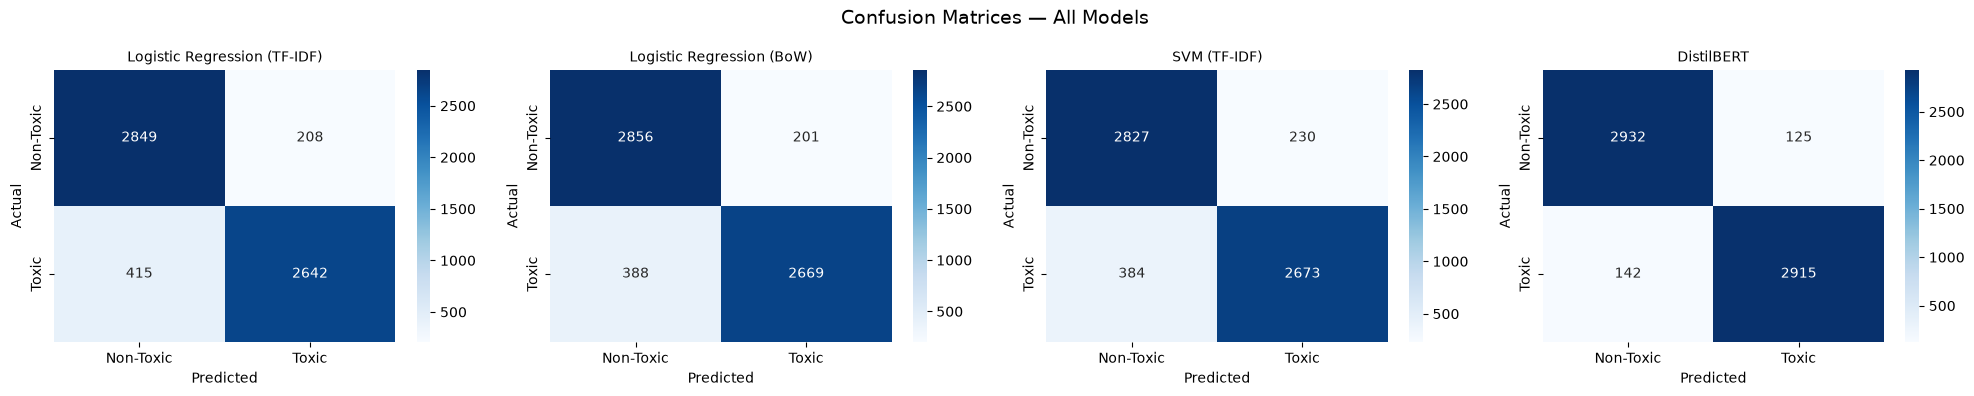

In [14]:
all_models = list(classical_cache.keys()) + ['DistilBERT']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, name in enumerate(all_models):
    if name == 'DistilBERT':
        y_pred_cm = all_preds
    else:
        entry = classical_cache[name]
        X_test_vec = entry['vec'].transform(X_test)
        y_pred_cm = entry['model'].predict(X_test_vec)

    cm = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-Toxic', 'Toxic'],
        yticklabels=['Non-Toxic', 'Toxic'],
        ax=axes[idx]
    )
    axes[idx].set_title(name, fontsize=10)
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

### 8.5 Model Comparison Chart

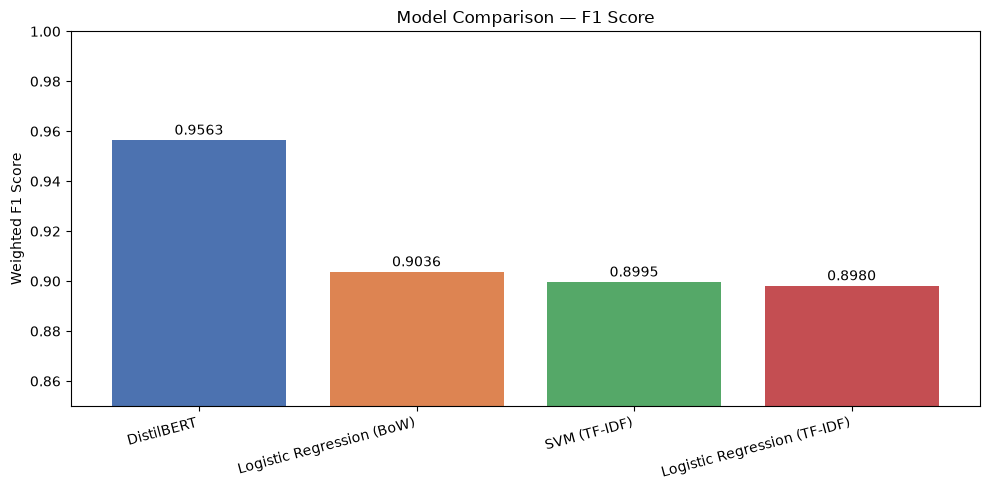

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(x, results_df['F1'], color=colors[:len(results_df)])
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Model Comparison — F1 Score')
ax.set_ylim(0.85, 1.0)
for bar, val in zip(bars, results_df['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Explainable AI (XAI)

We use two XAI methods:
- **LIME** for classical models; perturbs input to find word contributions
- **Attention weights** for DistilBERT; extracts internal attention scores from last layer

### 9.1 LIME for Classical Models

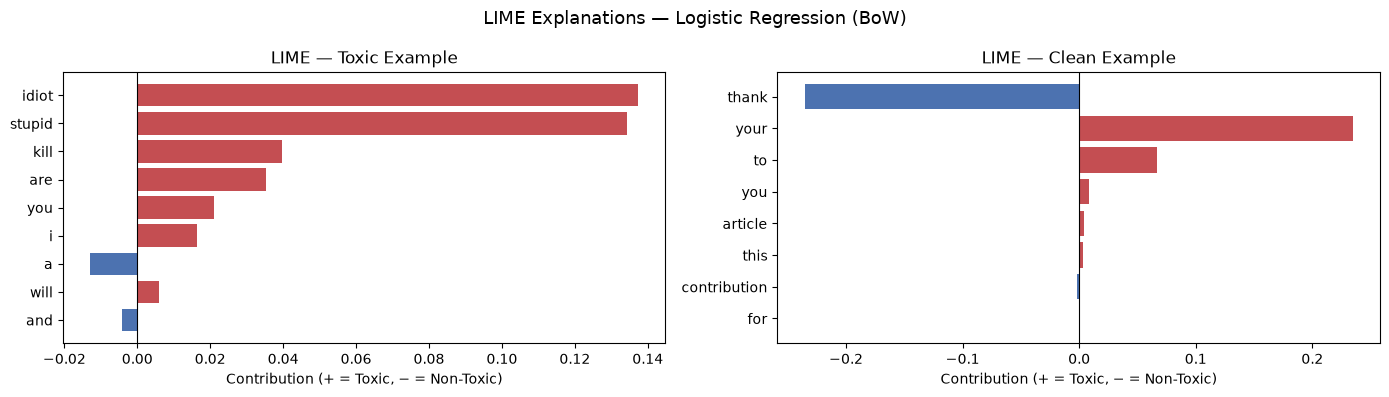

In [16]:
test_toxic = 'you are a stupid idiot and i will kill you'
test_clean = 'thank you for your contribution to this article'

def explain_classical_lime(text, model, vec, num_features=10):
    explainer = LimeTextExplainer(class_names=['Non-Toxic', 'Toxic'])
    def predict_fn(texts):
        vecs = vec.transform(texts)
        if hasattr(model, 'predict_proba'):
            return model.predict_proba(vecs)
        else:
            scores = model.decision_function(vecs)
            probs  = 1 / (1 + np.exp(-scores))
            return np.column_stack([1 - probs, probs])
    exp = explainer.explain_instance(
        text, predict_fn, num_features=num_features,
        num_samples=300, labels=[1]
    )
    return [(str(w), float(s)) for w, s in exp.as_list(label=1)]

# Use best classical model: LR + BoW
entry = classical_cache['Logistic Regression (BoW)']
model_lr = entry['model']
vec_lr   = entry['vec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for idx, (label, text) in enumerate([('Toxic', test_toxic), ('Clean', test_clean)]):
    exp = explain_classical_lime(text, model_lr, vec_lr)
    words  = [e[0] for e in exp]
    scores = [e[1] for e in exp]
    colors = ['#C44E52' if s > 0 else '#4C72B0' for s in scores]
    axes[idx].barh(words[::-1], scores[::-1], color=colors[::-1])
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(f'LIME — {label} Example')
    axes[idx].set_xlabel('Contribution (+ = Toxic, − = Non-Toxic)')

plt.suptitle('LIME Explanations — Logistic Regression (BoW)', fontsize=13)
plt.tight_layout()
plt.show()

### 9.2 Attention Weights for DistilBERT

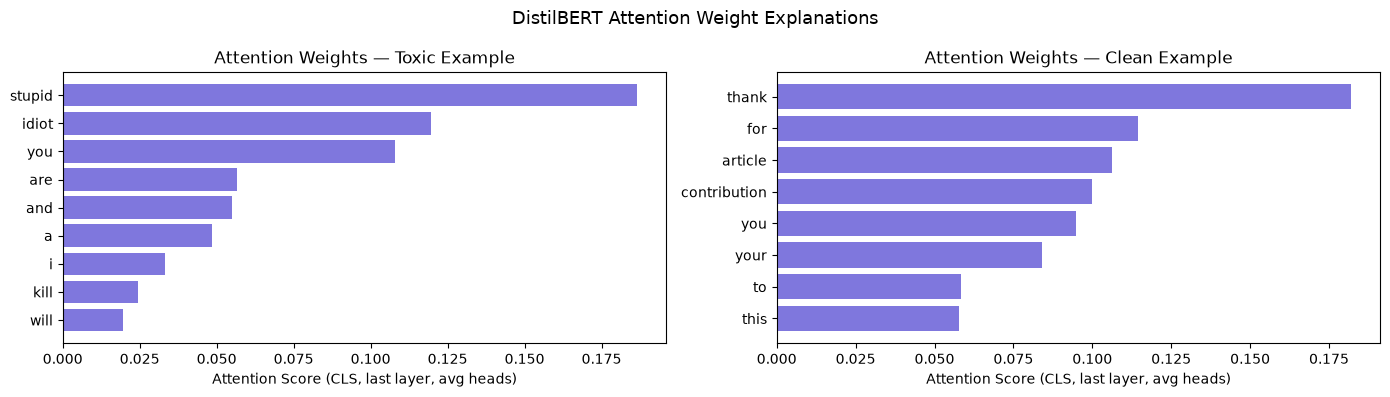

In [17]:
def explain_attention(text, model, tokenizer):
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LEN, padding=True
    )
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    last_attn = outputs.attentions[-1]
    avg_attn  = last_attn[0].mean(dim=0)
    cls_attn  = avg_attn[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    token_scores = [
        (tok, float(score))
        for tok, score in zip(tokens, cls_attn)
        if tok not in ('[CLS]', '[SEP]', '[PAD]')
    ]
    token_scores.sort(key=lambda x: x[1], reverse=True)
    return token_scores[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for idx, (label, text) in enumerate([('Toxic', test_toxic), ('Clean', test_clean)]):
    scores = explain_attention(text, bert_model, bert_tokenizer)
    tokens = [s[0] for s in scores]
    vals   = [s[1] for s in scores]
    axes[idx].barh(tokens[::-1], vals[::-1], color='#7F77DD')
    axes[idx].set_title(f'Attention Weights — {label} Example')
    axes[idx].set_xlabel('Attention Score (CLS, last layer, avg heads)')

plt.suptitle('DistilBERT Attention Weight Explanations', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Inference Demo

Live prediction on custom inputs across all models.

In [18]:
def predict_all(text):
    print(f'Input: "{text}"\n')
    for name, entry in classical_cache.items():
        vec   = entry['vec']
        model = entry['model']
        transformed = vec.transform([text])
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(transformed)[0]
            toxic_prob = probs[1]
        else:
            score = model.decision_function(transformed)[0]
            toxic_prob = 1 / (1 + np.exp(-score))
        label = 'TOXIC' if toxic_prob >= 0.5 else 'CLEAN'
        print(f'  {name:35s} → {label} ({toxic_prob*100:.1f}%)')

    # DistilBERT
    inputs = bert_tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LEN, padding=True
    )
    with torch.no_grad():
        outputs = bert_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0]
    toxic_prob = float(probs[1])
    label = 'TOXIC' if toxic_prob >= 0.5 else 'CLEAN'
    print(f'  {"DistilBERT":35s} → {label} ({toxic_prob*100:.1f}%)')

predict_all('you are a stupid idiot and i will kill you')
print()
predict_all('thank you for your wonderful contribution to wikipedia')
print()
predict_all('this article needs more citations and references')

Input: "you are a stupid idiot and i will kill you"

  Logistic Regression (TF-IDF)        → TOXIC (98.2%)
  Logistic Regression (BoW)           → TOXIC (100.0%)
  SVM (TF-IDF)                        → TOXIC (92.3%)
  DistilBERT                          → TOXIC (99.7%)

Input: "thank you for your wonderful contribution to wikipedia"

  Logistic Regression (TF-IDF)        → CLEAN (40.0%)
  Logistic Regression (BoW)           → CLEAN (42.6%)
  SVM (TF-IDF)                        → TOXIC (54.0%)
  DistilBERT                          → CLEAN (1.2%)

Input: "this article needs more citations and references"

  Logistic Regression (TF-IDF)        → CLEAN (35.4%)
  Logistic Regression (BoW)           → CLEAN (23.8%)
  SVM (TF-IDF)                        → CLEAN (30.5%)
  DistilBERT                          → CLEAN (0.9%)


## 11. Bilingual Support (English + Malay)

This section demonstrates multilingual toxic comment detection using:
- **Classical bilingual models** (LR, SVM, Naive Bayes × TF-IDF/BoW) trained on a balanced English+Malay corpus
- **XLM-RoBERTa** fine-tuned on the same corpus — a cross-lingual transformer with native Malay support

Language is auto-detected from the input text and routed to the appropriate model set.

In [ ]:
HF_REPO_XLM = 'lcokun/toxic-comment-xlm-roberta-bilingual'

BILINGUAL_MODELS = {
    'Logistic Regression (TF-IDF)': {
        'model': 'logistic_regression_tfidf_bilingual.joblib',
        'vec':   'vectorizer_tfidf_bilingual.joblib',
    },
    'Logistic Regression (BoW)': {
        'model': 'logistic_regression_bow_bilingual.joblib',
        'vec':   'vectorizer_bow_bilingual.joblib',
    },
    'SVM (TF-IDF)': {
        'model': 'svm_tfidf_bilingual.joblib',
        'vec':   'vectorizer_tfidf_bilingual.joblib',
    },
    'SVM (BoW)': {
        'model': 'svm_bow_bilingual.joblib',
        'vec':   'vectorizer_bow_bilingual.joblib',
    },
    'Naive Bayes (TF-IDF)': {
        'model': 'naive_bayes_tfidf_bilingual.joblib',
        'vec':   'vectorizer_tfidf_bilingual.joblib',
    },
    'Naive Bayes (BoW)': {
        'model': 'naive_bayes_bow_bilingual.joblib',
        'vec':   'vectorizer_bow_bilingual.joblib',
    },
}

print('Bilingual config set')

### 11.1 Load Bilingual Dataset

In [ ]:
url_bilingual = f'{GITHUB_RAW}/Data/balanced_corpus_fixed.csv'
df_bi = pd.read_csv(url_bilingual).dropna(subset=['preprocessed_text'])

print(f'Bilingual dataset shape: {df_bi.shape}')
print(f'\nPer-language class distribution:')
print(df_bi.groupby(['lang', 'toxic']).size())
df_bi.head()

### 11.2 Load Bilingual Classical Models

In [ ]:
bilingual_cache = {}
loaded_bi_vecs = {}

for name, paths in BILINGUAL_MODELS.items():
    print(f'Loading {name}...')
    vec_name = paths['vec']
    if vec_name not in loaded_bi_vecs:
        loaded_bi_vecs[vec_name] = load_joblib_from_github(vec_name)
    bilingual_cache[name] = {
        'model': load_joblib_from_github(paths['model']),
        'vec':   loaded_bi_vecs[vec_name],
    }
    print(f'  ✓ {name} loaded')

print('\nAll bilingual classical models loaded')

### 11.3 Load XLM-RoBERTa from HuggingFace Hub

In [ ]:
print(f'Loading XLM-RoBERTa from {HF_REPO_XLM}...')
xlm_tokenizer = AutoTokenizer.from_pretrained(HF_REPO_XLM)
xlm_model = AutoModelForSequenceClassification.from_pretrained(
    HF_REPO_XLM, output_attentions=True
)
xlm_model.eval()
print('XLM-RoBERTa loaded successfully')

### 11.4 Bilingual Model Evaluation

In [ ]:
X_bi = df_bi['preprocessed_text'].tolist()
y_bi = df_bi['toxic'].tolist()

_, X_bi_test, _, y_bi_test = train_test_split(
    X_bi, y_bi, test_size=0.3, random_state=SEED, stratify=y_bi
)
_, X_bi_test, _, y_bi_test = train_test_split(
    X_bi_test, y_bi_test, test_size=0.5, random_state=SEED, stratify=y_bi_test
)
print(f'Bilingual test set: {len(X_bi_test)} samples')

bi_results = []

# Classical bilingual models
for name, entry in bilingual_cache.items():
    model = entry['model']
    vec   = entry['vec']
    X_vec = vec.transform(X_bi_test)
    y_pred = model.predict(X_vec)
    acc = accuracy_score(y_bi_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_bi_test, y_pred, average='weighted')
    bi_results.append({'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                       'Recall': round(rec,4), 'F1': round(f1,4)})
    print(f'{name}: F1={f1:.4f}')

# XLM-RoBERTa
test_dataset_bi = TextDataset(X_bi_test, xlm_tokenizer, MAX_LEN)
loader_bi = DataLoader(test_dataset_bi, batch_size=32)
xlm_preds = []
with torch.no_grad():
    for batch in loader_bi:
        outputs = xlm_model(**batch)
        xlm_preds.extend(torch.argmax(outputs.logits, dim=-1).numpy())

acc = accuracy_score(y_bi_test, xlm_preds)
prec, rec, f1, _ = precision_recall_fscore_support(y_bi_test, xlm_preds, average='weighted')
bi_results.append({'Model': 'XLM-RoBERTa', 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                   'Recall': round(rec,4), 'F1': round(f1,4)})
print(f'XLM-RoBERTa: F1={f1:.4f}')

bi_results_df = pd.DataFrame(bi_results).sort_values('F1', ascending=False)
print()
print(bi_results_df.to_string(index=False))

### 11.5 Bilingual Inference Demo

In [ ]:
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        return 'ms' if detect(text) == 'ms' else 'en'
    except LangDetectException:
        return 'en'

def predict_bilingual(text):
    lang = detect_lang(text)
    lang_label = 'Malay' if lang == 'ms' else 'English'
    print(f'Input [{lang_label}]: "{text}"')

    for name, entry in bilingual_cache.items():
        vec   = entry['vec']
        model = entry['model']
        transformed = vec.transform([text])
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(transformed)[0]
            toxic_prob = probs[1]
        else:
            score = model.decision_function(transformed)[0]
            toxic_prob = 1 / (1 + np.exp(-score))
        label = 'TOXIC' if toxic_prob >= 0.5 else 'CLEAN'
        print(f'  {name:35s} → {label} ({toxic_prob*100:.1f}%)')

    # XLM-RoBERTa
    inputs = xlm_tokenizer(text, return_tensors='pt', truncation=True,
                           max_length=MAX_LEN, padding=True)
    with torch.no_grad():
        probs = torch.softmax(xlm_model(**inputs).logits, dim=-1)[0]
    toxic_prob = float(probs[1])
    label = 'TOXIC' if toxic_prob >= 0.5 else 'CLEAN'
    print(f'  {"XLM-RoBERTa":35s} → {label} ({toxic_prob*100:.1f}%)')
    print()

# English examples
predict_bilingual('you are a stupid idiot and i will kill you')
predict_bilingual('thank you for your contribution to this article')

# Malay examples
predict_bilingual('bodoh sial kau ni, pergi mampus')
predict_bilingual('terima kasih atas sokongan anda, sangat menghargai')